In [1]:
import sionna.rt as rt
import mitsuba as mi
import numpy as np
import drjit as dr
import matplotlib.pyplot as plt

In [2]:
N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
elevation = np.exp(-((vert_x-5)**2 + (vert_y-5)**2)) / 5
# elevation = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2 / 10
mesh = rt.utils.geometry.triangulate_elevation(mi.TensorXf(elevation), center=[0, 0, 0], size=[1, 1])
vertices = dr.reshape(mi.Point3f, mesh.vertex_positions_buffer(), (3, -1))

[[], [], Text(0.5, 1.0, 'Elevation')]

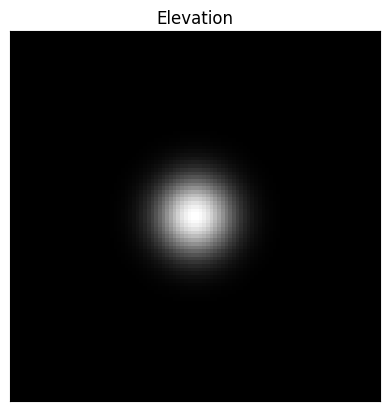

In [3]:
plt.imshow(elevation, cmap="gray")
plt.gca().set(xticks=[], yticks=[], title="Elevation")

In [4]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [5]:
# Create scene
props = mi.Properties()
props["material"] = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = rt.HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                  vertex_count=mesh.vertex_count(),
                  face_count=mesh.face_count(), 
                  props=props)
mesh_params = mi.traverse(mesh)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = dr.ravel(vertices)
mi_mesh_params["faces"] = mesh_params["faces"]
mi_mesh_params.update()
scene = rt.Scene(mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
}))

scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = rt.Transmitter(name="tx",
                #  position=mi.Point3f(0, 0, 0.1),
                 position=mi.Point3f(.2, .2, 0.1),
                 orientation=mi.Point3f(0,0,0),
                 power_dbm=100)
tx.display_radius = 0.01
scene.add(tx)

In [ ]:
sim_params = dict(
    max_depth = 3,
    los = True,
    specular_reflection=True,
    diffuse_reflection=True,
    refraction=True
)

# Compute the radio map
rm_solver = rt.RadioMapSolver()
rm = rm_solver(scene=scene,
               center=[0, 0, 0], 
               size=[1, 1],
               cell_size=[0.05, 0.05],
               # evaluate 5cm above the surface
               digital_elevation_model=mi.TensorXf(elevation) + 0.05,
               samples_per_tx=int(1e4),
               **sim_params)

# Check for NaN or Inf
assert not (dr.any(dr.isinf(rm.path_gain)) or dr.any(dr.isnan(rm.path_gain)))

: 

In [ ]:
rm.cell_centers